# Non Stationary Problem comparison

In [ ]:
from NonstationaryBandit import *

num_steps = 1000
n = 10
num_runs = 100
step_sizes = [1, 0.1, 0.01] 

# constant step size parameter
eps = 0.1
avg_rewards_cnst_stp = np.zeros((len(step_sizes), num_steps))
avg_optimal_cnst_stp = np.zeros((len(step_sizes), num_steps))
for i in range(num_runs):
    for j, step_size in enumerate(step_sizes):
        rewards, optimal = run_ns_bandit_cnst_step(init_bandit_ns, n, eps, num_steps, step_size)
        avg_rewards_cnst_stp[j] += (rewards - avg_rewards_cnst_stp[j])/(i+1)
        avg_optimal_cnst_stp[j] += (optimal - avg_optimal_cnst_stp[j])/(i+1)

# sample average step size parameter
epsilons = [1, 0.1, 0.01] 
avg_rewards_smpavg = np.zeros((len(epsilons), num_steps))
avg_optimal_smpavg = np.zeros((len(epsilons), num_steps))
for i in range(num_runs):
    for j, epsi in enumerate(epsilons):
        rewards, optimal = run_ns_greedy_bandit_sample_avg(init_bandit_ns, n, epsi, num_steps)
        avg_rewards_smpavg[j] += (rewards - avg_rewards_smpavg[j])/(i+1)
        avg_optimal_smpavg[j] += (optimal - avg_optimal_smpavg[j])/(i+1) 


# plotting
fig, axs = plt.subplots(2, 2, figsize=(8,10))

axs[0, 0].set_title(f"Average Reward and % Optimal Action for {n} bandit with Constant Step Size")
axs[0, 0].grid(True)
for j, step_size in enumerate(step_sizes):
    axs[0,0].plot(avg_rewards_cnst_stp[j][::10], label="step size = {}".format(step_size))
axs[0, 0].legend(loc="lower right")
axs[0, 0].set_ylabel("Average Reward")

axs[1, 0].grid(True)
for j, step_size in enumerate(step_sizes):
    axs[1,0].plot(avg_optimal_cnst_stp[j][::10], label="step size = {}".format(step_size))
axs[1, 0].legend(loc="lower right")
axs[1,0].set_xlabel("Steps")
axs[1,0].set_ylabel("% Optimal Action")


axs[0, 1].set_title(f"Average Reward and % Optimal Action for {n} bandit with sample average")
axs[0, 1].grid(True)
for j, epsi in enumerate(epsilons):
    axs[0,1].plot(avg_rewards_smpavg[j][::10], label="epsilon = {}".format(epsi))
axs[0, 1].legend(loc="lower right")
axs[0, 1].set_ylabel("Average Reward")

axs[1, 1].grid(True)
for j, epsi in enumerate(epsilons):
    axs[1,1].plot(avg_optimal_smpavg[j][::10], label="epsilon = {}".format(epsi))
axs[1, 1].legend(loc="lower right")
axs[1,1].set_xlabel("Steps")
axs[1,1].set_ylabel("% Optimal Action")

plt.show()

# Comparison between all Approaches for Non-Stationary Problem

In [1]:
# e-greedy constant step size

from NonstationaryBandit import *
import matplotlib.pyplot as plt
import numpy as np

params = [1/128, 1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1, 2, 4]
num_steps = 1000
n = 10
num_runs = 100

# e-greedy constant step size

# constant step size parameter, variable epsilon
step_size = 0.1 # alpha
eps = params
avg_rewards_cnst_stp = np.zeros((len(eps), num_steps))
avg_optimal_cnst_stp = np.zeros((len(eps), num_steps))
avg_last_rewards_cnst_stp_params = np.zeros(len(eps))
for i in range(num_runs):
    for j, epss in enumerate(eps):
        rewards, optimal = run_ns_bandit_cnst_step(init_bandit_ns, n, epss, num_steps, step_size)
        avg_rewards_cnst_stp[j] += (rewards - avg_rewards_cnst_stp[j])/(i+1)
        avg_optimal_cnst_stp[j] += (optimal - avg_optimal_cnst_stp[j])/(i+1)

for j, epss in enumerate(eps):
    avg_last_rewards_cnst_stp_params[j] = np.mean(avg_rewards_cnst_stp[j][int(0.5*num_steps):])

# plt.plot(eps, avg_last_rewards_cnst_stp_params)
# plt.xscale('log')

Here begins my testing with using multiprocessing to wrangle all this data. 
Need to convert all the functions to a set of worker functions, that can be pooled
also want to use my desktop pc to run the code, since it has more processing power.

Starting 500 simulations across 12 cores...
Simulations complete. Aggregating results...
Success! Final summary rewards per parameter:
[4.15482292 3.9391735  4.27033503 4.05825718 3.77535987 3.56537034
 2.3360594  0.02794741 0.09924591 0.03323561]


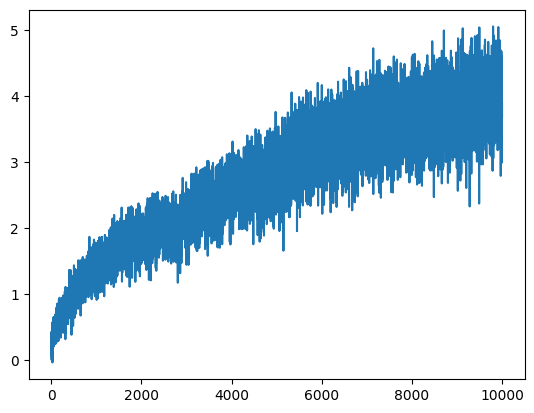

In [1]:
# multiprocessing 
import multiprocessing
import numpy as np
import matplotlib.pyplot as plt
from NonstationaryBandit import * # Ensure this is in the same directory

# 1. Define the worker function for a single simulation
def simulate_bandit(eps_val, n, num_steps, step_size):
    """Performs a single run of the bandit experiment."""
    rewards, optimal = run_ns_bandit_cnst_step(init_bandit_ns, n, eps_val, num_steps, step_size)
    return rewards, optimal

# Parameters
params = [1/128, 1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1, 2, 4]
num_steps = 100000
n = 10
num_runs = 50
step_size = 0.1

# 2. Prepare the list of tasks (Cartesian product of runs and params)
# Each task is a tuple of arguments for the simulate_bandit function
tasks = []
for eps_val in params:
    for _ in range(num_runs):
        tasks.append((eps_val, n, num_steps, step_size))

print(f"Starting {len(tasks)} simulations across {multiprocessing.cpu_count()} cores...")

# 3. Use a Pool to run simulations in parallel
with multiprocessing.Pool() as pool:
    # starmap allows passing multiple arguments to the function
    results = pool.starmap(simulate_bandit, tasks)

print("Simulations complete. Aggregating results...")

# 4. Reshape and aggregate the results
# results is a list of 1000 tuples: [(rewards, optimal), (rewards, optimal), ...]
# We split them into two arrays
all_rewards = np.array([res[0] for res in results]) # Shape: (1000, 200000)
all_optimal = np.array([res[1] for res in results])

# Reshape to (num_params, num_runs, num_steps) to easily average over runs
all_rewards = all_rewards.reshape(len(params), num_runs, num_steps)
all_optimal = all_optimal.reshape(len(params), num_runs, num_steps)

# Calculate the average across the 100 runs (axis 1)
avg_rewards_cnst_stp = np.mean(all_rewards, axis=1)
avg_optimal_cnst_stp = np.mean(all_optimal, axis=1)

# 5. Calculate final summary metric (mean of the second half of steps)
avg_last_rewards_cnst_stp_params = np.mean(avg_rewards_cnst_stp[:, int(0.5*num_steps):], axis=1)

print("Success! Final summary rewards per parameter:")
print(avg_last_rewards_cnst_stp_params)
plt.plot(avg_rewards_cnst_stp[5,::10])

In [2]:
# e-greedy average
from NonstationaryBandit import *
import matplotlib.pyplot as plt
import numpy as np

params = [1/128, 1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1, 2, 4]
num_steps = 1000
n = 10
num_runs = 100

# e-greedy average
# variable epsilon
eps = params
avg_rewards_eps = np.zeros((len(eps), num_steps))
avg_optimal_eps = np.zeros((len(eps), num_steps))
avg_last_rewards_eps_params = np.zeros(len(eps))
for i in range(num_runs):
    for j, epss in enumerate(eps):
        rewards, optimal = run_ns_greedy_bandit_sample_avg(init_bandit_ns, n, epss, num_steps)
        avg_rewards_eps[j] += (rewards - avg_rewards_eps[j])/(i+1)
        avg_optimal_eps[j] += (optimal - avg_optimal_eps[j])/(i+1)

for j, epss in enumerate(eps):
    avg_last_rewards_eps_params[j] = np.mean(avg_rewards_eps[j][int(0.5*num_steps):])

# plt.plot(eps, avg_last_rewards_eps_params)
# plt.xscale('log')
# plt.plot(avg_optimal_eps[4])

In [3]:
%load_ext autoreload
%autoreload 2
# e-greedy unbiased step size
from NonstationaryBandit import *
import matplotlib.pyplot as plt
import numpy as np

params = [1/128, 1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1, 2, 4]
num_steps = 2000
n = 10
num_runs = 100

# e-greedy unbiased step size

step_sizes = params[:7] # alpha
eps = 0.1
avg_rewards_unbiased = np.zeros((len(step_sizes), num_steps))
avg_optimal_unbiased = np.zeros((len(step_sizes), num_steps))
avg_last_rewards_unbiased_params = np.zeros(len(step_sizes))
for i in range(num_runs):
    for j, step_size in enumerate(step_sizes):
        rewards, optimal = run_ns_greedy_unbiased_step_size(init_bandit_ns, n, eps, num_steps, step_size)
        avg_rewards_unbiased[j] += (rewards - avg_rewards_unbiased[j])/(i+1)
        avg_optimal_unbiased[j] += (optimal - avg_optimal_unbiased[j])/(i+1)

for j, step_size in enumerate(step_sizes):
    avg_last_rewards_unbiased_params[j] = np.mean(avg_rewards_unbiased[j][int(0.5*num_steps):])

# plt.plot(step_sizes, avg_last_rewards_unbiased_params)
# plt.xscale('log')

In [ ]:
# UCB bandit
%load_ext autoreload
%autoreload 2
from NonstationaryBandit import *
import matplotlib.pyplot as plt
import numpy as np

params = [1/128, 1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1, 2, 4]
num_steps = 1000
n = 10
num_runs = 100

# UCB bandit

cs = params # alpha
avg_rewards_ucb = np.zeros((len(cs), num_steps))
avg_optimal_ucb = np.zeros((len(cs), num_steps))
avg_last_rewards_ucb_params = np.zeros(len(cs))
for i in range(num_runs):
    for j, c in enumerate(cs):
        rewards, optimal = run_ns_UCB_bandit_sample_avg(init_bandit_ns, n, c, num_steps)
        avg_rewards_ucb[j] += (rewards - avg_rewards_ucb[j])/(i+1)
        avg_optimal_ucb[j] += (optimal - avg_optimal_ucb[j])/(i+1)

for j, c in enumerate(cs):
    avg_last_rewards_ucb_params[j] = np.mean(avg_rewards_ucb[j][int(0.5*num_steps):])

# plt.plot(cs, avg_last_rewards_ucb_params)
# plt.xscale('log')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# gradient bandit
%load_ext autoreload
%autoreload 2
from NonstationaryBandit import *
import matplotlib.pyplot as plt
import numpy as np

params = [1/128, 1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1, 2, 4]
num_steps = 1000
n = 10
num_runs = 100

# gradient bandit

set_alpha_gradient = params # alpha
avg_rewards_grad = np.zeros((len(set_alpha_gradient), num_steps))
avg_optimal_grad = np.zeros((len(set_alpha_gradient), num_steps))
avg_last_rewards_grad_params = np.zeros(len(set_alpha_gradient))
for i in range(num_runs):
    for j, alpha in enumerate(set_alpha_gradient):
        rewards, optimal = run_ns_Gradient_bandit(init_bandit_ns, n, alpha, num_steps)
        avg_rewards_grad[j] += (rewards - avg_rewards_grad[j])/(i+1)
        avg_optimal_grad[j] += (optimal - avg_optimal_grad[j])/(i+1)

for j, alpha in enumerate(set_alpha_gradient):
    avg_last_rewards_grad_params[j] = np.mean(avg_rewards_grad[j][int(0.5*num_steps):])

# plt.plot(set_alpha_gradient, avg_last_rewards_grad_params)
# plt.xscale('log')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


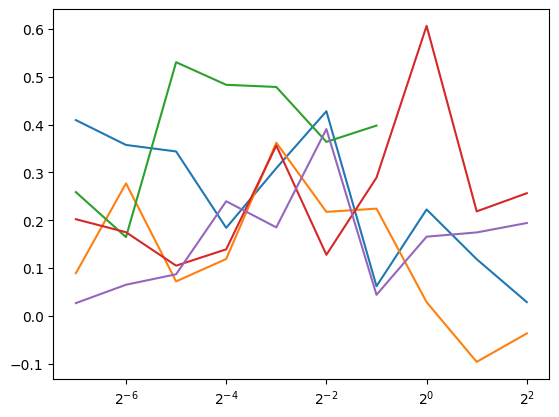

In [ ]:
# plotting
plt.plot(params, avg_last_rewards_cnst_stp_params, label="e-greedy constant step size")
plt.plot(params, avg_last_rewards_eps_params, label="e-greedy average")
plt.plot(params[:7], avg_last_rewards_unbiased_params, label="e-greedy unbiased step size")
plt.plot(params, avg_last_rewards_ucb_params, label = 'UCB bandit')
plt.plot(params, avg_last_rewards_grad_params, label="gradient bandit")
plt.xscale('log', base=2)

